# LSTM Gold Return Prediction

## 1. Setup and Data Loading

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
DATA_PATH = "daily_commodity_market_data_cleaned.csv"
TARGET_COLUMN = "tomorrow_gold_log_return"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"],
    index_col="Date",
).sort_index()

print("Shape:", df.shape)
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Duplicate dates:", df.index.duplicated().sum())
print("Missing values:", df.isna().sum().sum())
print("Target present:", TARGET_COLUMN in df.columns)

df.head()

Shape: (5016, 22)
Start date: 2004-01-22 00:00:00
End date: 2026-07-13 00:00:00
Duplicate dates: 0
Missing values: 0
Target present: True


,tomorrow_gold_log_return,gold_return_1d,gold_return_5d,gold_return_20d,gold_volatility_5d,gold_volatility_20d,gold_close_pos,gold_volume_change,gold_relative_volume,crude_oil_return_1d,...,platinum_return_1d,us_dollar_index_return_1d,sp_500_return_1d,eur_usd_return_1d,vix_change_1d,breakeven_inflation_10y_diff_bps,us_2_year_treasury_yields_diff_bps,us_10_year_treasury_yields_diff_bps,two_ten_slope,two_ten_slope_change_bps
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-22,-0.005135,-0.002679,-0.028137,-0.000975,0.016754,0.010122,0.5,0.000000,0.060060,0.010071,...,0.011614,-0.006273,-0.003212,0.005204,0.37,-3.0,-3.0,-6.0,2.33,-3.0
2004-01-23,-0.003192,-0.005135,-0.001225,-0.003182,0.008370,0.010167,0.5,0.000000,0.069686,0.000286,...,0.002056,0.008586,-0.002091,-0.011224,0.13,4.0,5.0,10.0,2.38,5.0
2004-01-26,0.008327,-0.003192,-0.000246,-0.009790,0.008266,0.010153,0.5,0.000000,0.076336,-0.013543,...,-0.018656,0.007940,0.012034,-0.007584,-0.29,0.0,4.0,7.0,2.41,3.0
2004-01-27,0.010916,0.008327,-0.006564,-0.002436,0.005467,0.010340,0.5,0.000000,0.117302,-0.010206,...,0.010177,-0.011180,-0.009846,0.011859,0.80,0.0,-5.0,-5.0,2.41,0.0
2004-01-28,-0.039365,0.010916,0.008236,0.005322,0.007394,0.010611,0.5,10.146747,19.954106,-0.014763,...,-0.022104,0.007965,-0.013703,-0.015548,1.43,3.0,17.0,11.0,2.35,-6.0


## 2. Chronological Train, Validation, and Test Split

In [3]:
# Separate predictor features and target
feature_columns = [col for col in df.columns if col != TARGET_COLUMN]

X = df[feature_columns]
y = df[[TARGET_COLUMN]]

print("Number of predictor features:", len(feature_columns))
print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Number of predictor features: 21
Predictor shape: (5016, 21)
Target shape: (5016, 1)


In [4]:
# Chronological split: 70% training, 15% validation, 15% testing
train_ratio = 0.70
validation_ratio = 0.15

train_end = int(len(df) * train_ratio)
validation_end = int(len(df) * (train_ratio + validation_ratio))

X_train_raw = X.iloc[:train_end]
X_validation_raw = X.iloc[train_end:validation_end]
X_test_raw = X.iloc[validation_end:]

y_train_raw = y.iloc[:train_end]
y_validation_raw = y.iloc[train_end:validation_end]
y_test_raw = y.iloc[validation_end:]

print("Training rows:", len(X_train_raw))
print("Validation rows:", len(X_validation_raw))
print("Testing rows:", len(X_test_raw))

print("\nTraining period:")
print(X_train_raw.index.min(), "to", X_train_raw.index.max())

print("\nValidation period:")
print(X_validation_raw.index.min(), "to", X_validation_raw.index.max())

print("\nTesting period:")
print(X_test_raw.index.min(), "to", X_test_raw.index.max())

Training rows: 3511
Validation rows: 752
Testing rows: 753

Training period:
2004-01-22 00:00:00 to 2020-07-13 00:00:00

Validation period:
2020-07-14 00:00:00 to 2023-07-10 00:00:00

Testing period:
2023-07-11 00:00:00 to 2026-07-13 00:00:00


## 3. Feature and Target Scaling

In [5]:
# Create separate scalers for predictors and target
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit only on the training data to prevent leakage
X_train_scaled = feature_scaler.fit_transform(X_train_raw)
X_validation_scaled = feature_scaler.transform(X_validation_raw)
X_test_scaled = feature_scaler.transform(X_test_raw)

y_train_scaled = target_scaler.fit_transform(y_train_raw)
y_validation_scaled = target_scaler.transform(y_validation_raw)
y_test_scaled = target_scaler.transform(y_test_raw)

print("Scaled training predictors:", X_train_scaled.shape)
print("Scaled validation predictors:", X_validation_scaled.shape)
print("Scaled testing predictors:", X_test_scaled.shape)

print("Scaled training target:", y_train_scaled.shape)
print("Scaled validation target:", y_validation_scaled.shape)
print("Scaled testing target:", y_test_scaled.shape)

print("\nTraining feature mean after scaling:",
      round(float(X_train_scaled.mean()), 6))
print("Training feature standard deviation after scaling:",
      round(float(X_train_scaled.std()), 6))

Scaled training predictors: (3511, 21)
Scaled validation predictors: (752, 21)
Scaled testing predictors: (753, 21)
Scaled training target: (3511, 1)
Scaled validation target: (752, 1)
Scaled testing target: (753, 1)

Training feature mean after scaling: -0.0
Training feature standard deviation after scaling: 1.0


## 4. Create LSTM Sequences

In [6]:
LOOKBACK = 30


def create_training_sequences(X_data, y_data, lookback):
    X_sequences = []
    y_sequences = []

    # Each sequence ends on the same row as its target.
    for i in range(lookback - 1, len(X_data)):
        X_sequences.append(X_data[i - lookback + 1:i + 1])
        y_sequences.append(y_data[i])

    return np.array(X_sequences), np.array(y_sequences)


def create_boundary_sequences(
    previous_X,
    current_X,
    current_y,
    lookback
):
    # Only lookback - 1 prior observations are needed because
    # the current row is included in each prediction window.
    combined_X = np.concatenate([
        previous_X[-(lookback - 1):],
        current_X
    ])

    X_sequences = []
    y_sequences = []

    for i in range(len(current_X)):
        X_sequences.append(combined_X[i:i + lookback])
        y_sequences.append(current_y[i])

    return np.array(X_sequences), np.array(y_sequences)

In [7]:
X_train_seq, y_train_seq = create_training_sequences(
    X_train_scaled,
    y_train_scaled,
    LOOKBACK
)

X_validation_seq, y_validation_seq = create_boundary_sequences(
    X_train_scaled,
    X_validation_scaled,
    y_validation_scaled,
    LOOKBACK
)

X_test_seq, y_test_seq = create_boundary_sequences(
    X_validation_scaled,
    X_test_scaled,
    y_test_scaled,
    LOOKBACK
)

print("Training:", X_train_seq.shape, y_train_seq.shape)
print("Validation:", X_validation_seq.shape, y_validation_seq.shape)
print("Testing:", X_test_seq.shape, y_test_seq.shape)

Training: (3482, 30, 21) (3482, 1)
Validation: (752, 30, 21) (752, 1)
Testing: (753, 30, 21) (753, 1)


## 5. Baseline LSTM Model

In [8]:
baseline_model = Sequential([
    Input(shape=(LOOKBACK, len(feature_columns))),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = baseline_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_validation_seq, y_validation_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0439 - val_loss: 0.7267
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9903 - val_loss: 0.7236
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9615 - val_loss: 0.7245
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9466 - val_loss: 0.7280
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9240 - val_loss: 0.7333
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9035 - val_loss: 0.7392
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8771 - val_loss: 0.7494
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8596 - val_loss: 0.7545
Epoch 9/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8441 - val_loss: 0.7773
Epoch 10/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8317 - val_loss: 0.7693
Epoch 11/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7994 - val_loss: 0.7844
Epoch 12/100
109/109 ━━━━━━━━━━━━━━━━━━━━

## 6. Baseline LSTM Evaluation

### 6.1 Generate Predictions

In [10]:
# Generate predictions on the unseen test set
y_test_pred_scaled = baseline_model.predict(X_test_seq)

# Convert predictions and actual values back to the original return scale
y_test_pred = target_scaler.inverse_transform(
    y_test_pred_scaled
).ravel()

y_test_actual = target_scaler.inverse_transform(
    y_test_seq
).ravel()

# The corrected sequence construction retains every test observation
test_dates = y_test_raw.index

print("Predictions shape:", y_test_pred.shape)
print("Actual values shape:", y_test_actual.shape)
print("Test dates shape:", test_dates.shape)

assert len(y_test_pred) == len(y_test_actual)
assert len(test_dates) == len(y_test_actual)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predictions shape: (753,)
Actual values shape: (753,)
Test dates shape: (753,)


### 6.2 Calculate Baseline LSTM Metrics

In [11]:
baseline_mae = mean_absolute_error(
    y_test_actual,
    y_test_pred
)

baseline_mse = mean_squared_error(
    y_test_actual,
    y_test_pred
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(
    y_test_actual,
    y_test_pred
)

baseline_directional_accuracy = np.mean(
    np.sign(y_test_actual) == np.sign(y_test_pred)
)

print("Baseline LSTM Test Results")
print(f"MAE: {baseline_mae:.8f}")
print(f"MSE: {baseline_mse:.8f}")
print(f"RMSE: {baseline_rmse:.8f}")
print(f"R²: {baseline_r2:.4f}")
print(
    f"Directional Accuracy: "
    f"{baseline_directional_accuracy:.4%}"
)

Baseline LSTM Test Results
MAE: 0.00915828
MSE: 0.00017412
RMSE: 0.01319549
R²: 0.0006
Directional Accuracy: 55.7769%


### 6.3 Zero-Return Baseline

In [12]:
# Naive baseline: predict no change in gold for every test observation
zero_predictions = np.zeros_like(y_test_actual)

zero_mae = mean_absolute_error(
    y_test_actual,
    zero_predictions
)

zero_mse = mean_squared_error(
    y_test_actual,
    zero_predictions
)

zero_rmse = np.sqrt(zero_mse)

zero_r2 = r2_score(
    y_test_actual,
    zero_predictions
)

print("Zero-Return Baseline Results")
print(f"MAE: {zero_mae:.8f}")
print(f"MSE: {zero_mse:.8f}")
print(f"RMSE: {zero_rmse:.8f}")
print(f"R²: {zero_r2:.4f}")
print("Directional Accuracy: Not applicable")

Zero-Return Baseline Results
MAE: 0.00919469
MSE: 0.00017520
RMSE: 0.01323640
R²: -0.0056
Directional Accuracy: Not applicable


### 6.4 Baseline Model Comparison

In [13]:
baseline_comparison = pd.DataFrame({
    "Model": [
        "Zero-Return Baseline",
        "Baseline LSTM"
    ],
    "MAE": [
        zero_mae,
        baseline_mae
    ],
    "MSE": [
        zero_mse,
        baseline_mse
    ],
    "RMSE": [
        zero_rmse,
        baseline_rmse
    ],
    "R2": [
        zero_r2,
        baseline_r2
    ],
    "Directional_Accuracy": [
        np.nan,
        baseline_directional_accuracy
    ]
})

baseline_comparison

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN
1,Baseline LSTM,0.009158,0.000174,0.013195,0.000614,0.557769


### 6.5 Training and Validation Loss

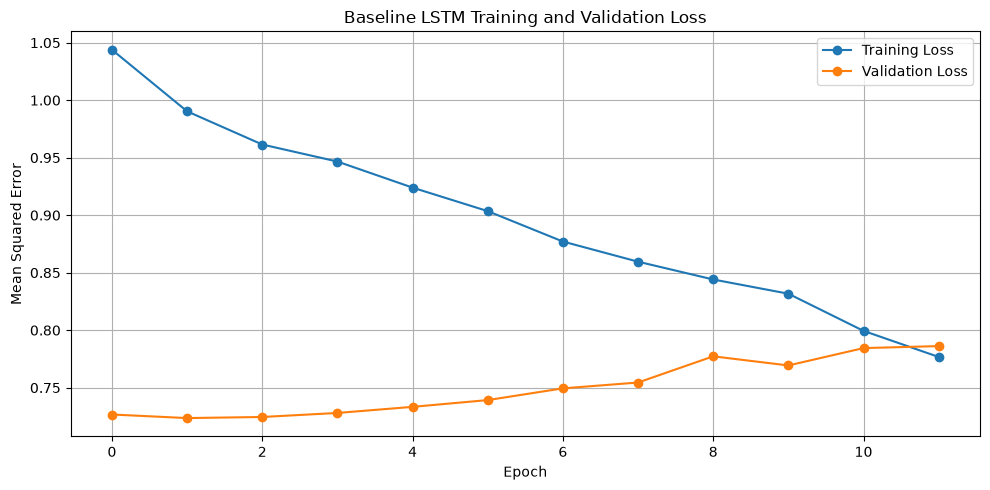

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Baseline LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 6.6 Actual Versus Predicted Test Returns

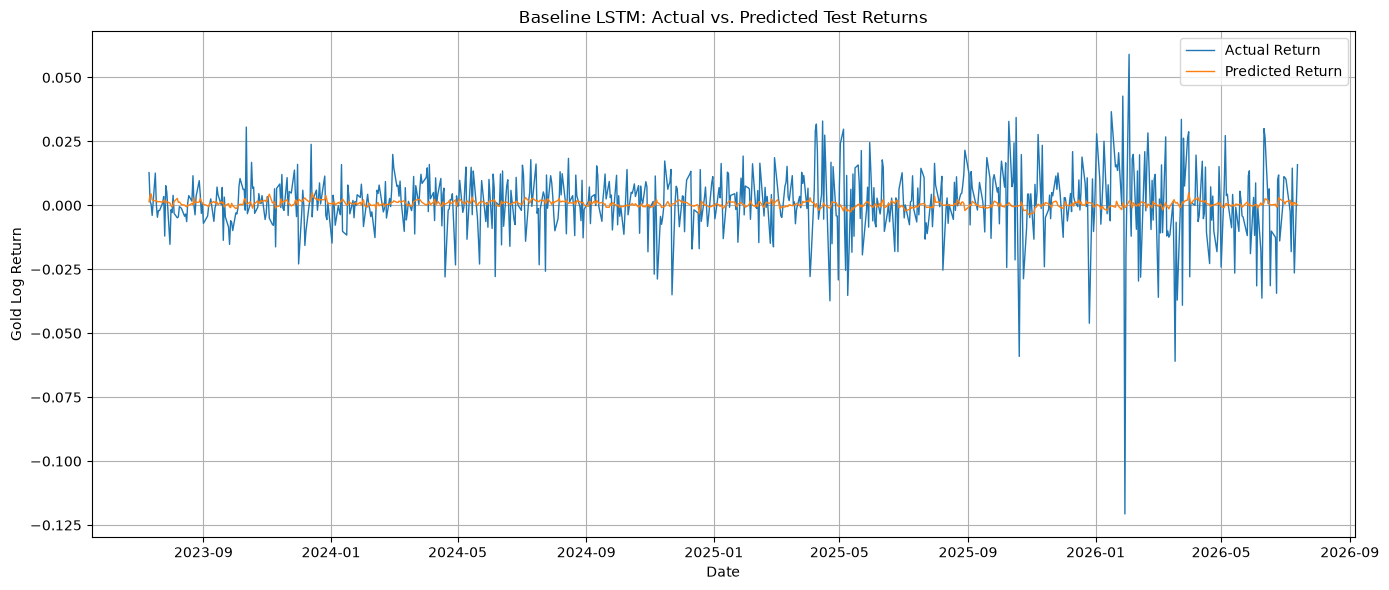

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test_actual,
    label="Actual Return",
    linewidth=1
)

plt.plot(
    test_dates,
    y_test_pred,
    label="Predicted Return",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Gold Log Return")
plt.title("Baseline LSTM: Actual vs. Predicted Test Returns")
plt.legend()
plt.grid(True)

plt.tight_layout()

### 6.7 Prediction Results Table

In [16]:
baseline_predictions = pd.DataFrame({
    "Date": test_dates,
    "Actual_Return": y_test_actual,
    "Predicted_Return": y_test_pred
})

baseline_predictions.head()

,Date,Actual_Return,Predicted_Return
0,2023-07-11,0.012810,0.001436
1,2023-07-12,0.001532,0.003837
2,2023-07-13,0.000459,0.004483
3,2023-07-14,-0.003936,0.002120
4,2023-07-17,0.012622,0.001734


### 6.8 Residual Analysis

In [17]:
baseline_predictions["Residual"] = (
    baseline_predictions["Actual_Return"]
    - baseline_predictions["Predicted_Return"]
)

print(
    baseline_predictions[
        [
            "Actual_Return",
            "Predicted_Return",
            "Residual"
        ]
    ].describe()
)   

       Actual_Return  Predicted_Return    Residual
count     753.000000        753.000000  753.000000
mean        0.000987          0.000586    0.000401
std         0.013208          0.001133    0.013198
min        -0.120657         -0.003663   -0.119855
25%        -0.004733         -0.000155   -0.005240
50%         0.001489          0.000574    0.000816
75%         0.007958          0.001340    0.007788
max         0.059054          0.004973    0.057452


### 6.9 Residuals Over Time

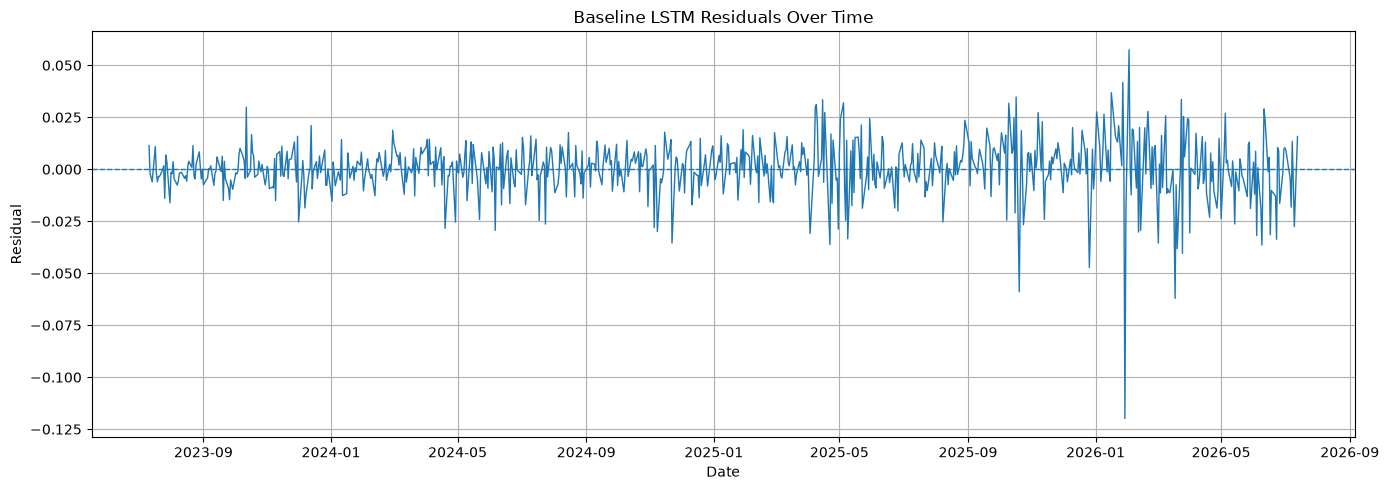

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    baseline_predictions["Date"],
    baseline_predictions["Residual"],
    linewidth=1
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Baseline LSTM Residuals Over Time")
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. LSTM Hyperparameter Tuning

### 7.1 Tuning Strategy

A controlled manual search is used to compare several LSTM configurations. The search varies the number of LSTM units, dropout rate, learning rate, and batch size. Candidate models are compared using validation loss only; the test set remains untouched until the final tuned model is selected.

### 7.2 Define Candidate Hyperparameters

In [20]:
# Define a small, controlled hyperparameter search space
tuning_configs = [
    {
        "config_id": 1,
        "lstm_units": 16,
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "config_id": 2,
        "lstm_units": 32,
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "config_id": 3,
        "lstm_units": 32,
        "dropout_rate": 0.3,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "config_id": 4,
        "lstm_units": 32,
        "dropout_rate": 0.4,
        "learning_rate": 0.0005,
        "batch_size": 32
    },
    {
        "config_id": 5,
        "lstm_units": 64,
        "dropout_rate": 0.3,
        "learning_rate": 0.0005,
        "batch_size": 64
    }
]

tuning_configs_df = pd.DataFrame(tuning_configs)
tuning_configs_df

,config_id,lstm_units,dropout_rate,learning_rate,batch_size
0,1,16,0.2,0.0010,32
1,2,32,0.2,0.0010,32
2,3,32,0.3,0.0010,32
3,4,32,0.4,0.0005,32
4,5,64,0.3,0.0005,64


### 7.3 Build Tunable LSTM Models



In [21]:
def build_lstm_model(
    lstm_units,
    dropout_rate,
    learning_rate
):
    model = Sequential([
        Input(shape=(LOOKBACK, len(feature_columns))),
        LSTM(lstm_units),
        Dropout(dropout_rate),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    return model

In [23]:
test_tuning_model = build_lstm_model(
    lstm_units=tuning_configs[0]["lstm_units"],
    dropout_rate=tuning_configs[0]["dropout_rate"],
    learning_rate=tuning_configs[0]["learning_rate"]
)

test_tuning_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 16)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,449 (9.57 KB)

 Trainable params: 2,449 (9.57 KB)

 Non-trainable params: 0 (0.00 B)

### 7.4 Train Candidate Models



In [25]:
tuning_results = []
tuning_histories = {}
tuning_models = {}

for config in tuning_configs:
    config_id = config["config_id"]

    print("=" * 70)
    print(f"Training configuration {config_id}")
    print(config)

    # Reset seeds before each model for more consistent comparisons
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_lstm_model(
        lstm_units=config["lstm_units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"]
    )

    tuning_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model_history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(
            X_validation_seq,
            y_validation_seq
        ),
        epochs=100,
        batch_size=config["batch_size"],
        callbacks=[tuning_early_stopping],
        shuffle=False,
        verbose=0
    )

    best_epoch = int(
        np.argmin(model_history.history["val_loss"]) + 1
    )

    best_validation_loss = float(
        np.min(model_history.history["val_loss"])
    )

    tuning_results.append({
        **config,
        "epochs_trained": len(
            model_history.history["loss"]
        ),
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss
    })

    tuning_histories[config_id] = model_history
    tuning_models[config_id] = model

    print(f"Epochs trained: {len(model_history.history['loss'])}")
    print(f"Best epoch: {best_epoch}")
    print(
        f"Best validation loss: "
        f"{best_validation_loss:.8f}"
    )

Training configuration 1
{'config_id': 1, 'lstm_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epochs trained: 19
Best epoch: 9
Best validation loss: 0.73547435
Training configuration 2
{'config_id': 2, 'lstm_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epochs trained: 12
Best epoch: 2
Best validation loss: 0.72624117
Training configuration 3
{'config_id': 3, 'lstm_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}
Epochs trained: 12
Best epoch: 2
Best validation loss: 0.72519976
Training configuration 4
{'config_id': 4, 'lstm_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.0005, 'batch_size': 32}
Epochs trained: 12
Best epoch: 2
Best validation loss: 0.72375059
Training configuration 5
{'config_id': 5, 'lstm_units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
Epochs trained: 15
Best epoch: 5
Best validation loss: 0.72276920


### 7.5 Compare Validation Performance

In [26]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="best_validation_loss",
    ascending=True
).reset_index(drop=True)

tuning_results_df

,config_id,lstm_units,dropout_rate,learning_rate,batch_size,epochs_trained,best_epoch,best_validation_loss
0,5,64,0.3,0.0005,64,15,5,0.722769
1,4,32,0.4,0.0005,32,12,2,0.723751
2,3,32,0.3,0.0010,32,12,2,0.725200
3,2,32,0.2,0.0010,32,12,2,0.726241
4,1,16,0.2,0.0010,32,19,9,0.735474


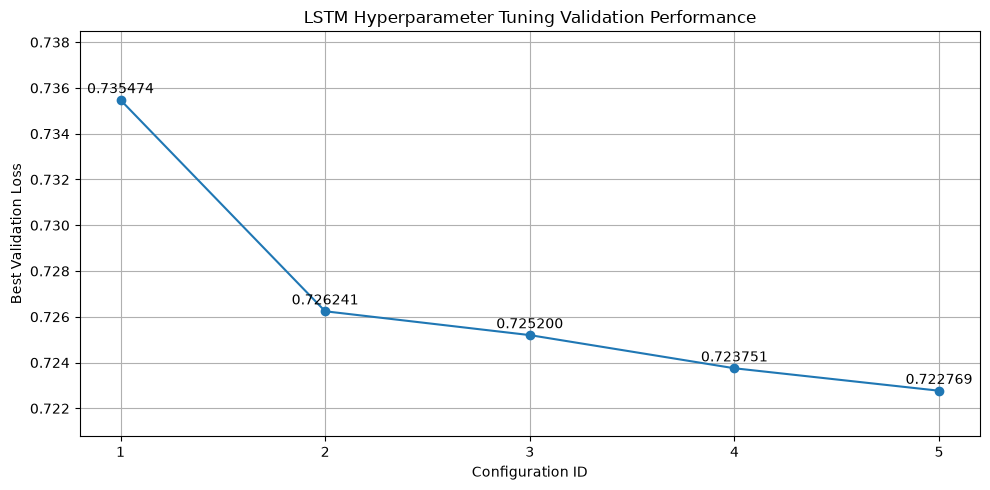

In [30]:
plot_results_df = tuning_results_df.sort_values(
    by="config_id"
)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_results_df["config_id"].astype(str),
    plot_results_df["best_validation_loss"],
    marker="o"
)

for _, row in plot_results_df.iterrows():
    plt.text(
        str(int(row["config_id"])),
        row["best_validation_loss"] + 0.0003,
        f'{row["best_validation_loss"]:.6f}',
        ha="center"
    )

minimum_loss = plot_results_df["best_validation_loss"].min()
maximum_loss = plot_results_df["best_validation_loss"].max()

plt.ylim(
    minimum_loss - 0.002,
    maximum_loss + 0.003
)

plt.xlabel("Configuration ID")
plt.ylabel("Best Validation Loss")
plt.title("LSTM Hyperparameter Tuning Validation Performance")
plt.grid(True)

plt.tight_layout()
plt.show()

### 7.6 Select Best Hyperparameters

In [31]:
best_result = tuning_results_df.iloc[0]

best_config_id = int(best_result["config_id"])

best_config = {
    "config_id": best_config_id,
    "lstm_units": int(best_result["lstm_units"]),
    "dropout_rate": float(best_result["dropout_rate"]),
    "learning_rate": float(best_result["learning_rate"]),
    "batch_size": int(best_result["batch_size"]),
    "best_epoch": int(best_result["best_epoch"]),
    "best_validation_loss": float(
        best_result["best_validation_loss"]
    )
}

print("Selected Best Hyperparameters")
for key, value in best_config.items():
    print(f"{key}: {value}")

Selected Best Hyperparameters
config_id: 5
lstm_units: 64
dropout_rate: 0.3
learning_rate: 0.0005
batch_size: 64
best_epoch: 5
best_validation_loss: 0.7227692008018494


### 7.7 Train Final Tuned LSTM

In [32]:
# Reset random seeds before training the final tuned model
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tuned_model = build_lstm_model(
    lstm_units=best_config["lstm_units"],
    dropout_rate=best_config["dropout_rate"],
    learning_rate=best_config["learning_rate"]
)

tuned_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuned_history = tuned_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_validation_seq,
        y_validation_seq
    ),
    epochs=100,
    batch_size=best_config["batch_size"],
    callbacks=[tuned_early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.0652 - val_loss: 0.7424
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0224 - val_loss: 0.7314
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.0023 - val_loss: 0.7279
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9917 - val_loss: 0.7246
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9862 - val_loss: 0.7228
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9700 - val_loss: 0.7237
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9690 - val_loss: 0.7251
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9500 - val_loss: 0.7250
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9480 - val_loss: 0.7286
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9420 - val_loss: 0.7318
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9220 - val_loss: 0.7335
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - los

In [33]:
tuned_best_epoch = int(
    np.argmin(tuned_history.history["val_loss"]) + 1
)

tuned_best_validation_loss = float(
    np.min(tuned_history.history["val_loss"])
)

print("Final Tuned LSTM Training Summary")
print(f"Epochs trained: {len(tuned_history.history['loss'])}")
print(f"Best epoch: {tuned_best_epoch}")
print(
    f"Best validation loss: "
    f"{tuned_best_validation_loss:.8f}"
)

Final Tuned LSTM Training Summary
Epochs trained: 15
Best epoch: 5
Best validation loss: 0.72276920


### 7.8 Evaluate Tuned LSTM on Test Data

In [34]:
# Generate predictions from the final tuned model
y_test_tuned_pred_scaled = tuned_model.predict(X_test_seq)

# Convert predictions back to the original return scale
y_test_tuned_pred = target_scaler.inverse_transform(
    y_test_tuned_pred_scaled
).ravel()

print("Tuned predictions shape:", y_test_tuned_pred.shape)
print("Actual values shape:", y_test_actual.shape)

assert len(y_test_tuned_pred) == len(y_test_actual)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Tuned predictions shape: (753,)
Actual values shape: (753,)


In [35]:
tuned_mae = mean_absolute_error(
    y_test_actual,
    y_test_tuned_pred
)

tuned_mse = mean_squared_error(
    y_test_actual,
    y_test_tuned_pred
)

tuned_rmse = np.sqrt(tuned_mse)

tuned_r2 = r2_score(
    y_test_actual,
    y_test_tuned_pred
)

tuned_directional_accuracy = np.mean(
    np.sign(y_test_actual) == np.sign(y_test_tuned_pred)
)

print("Tuned LSTM Test Results")
print(f"MAE: {tuned_mae:.8f}")
print(f"MSE: {tuned_mse:.8f}")
print(f"RMSE: {tuned_rmse:.8f}")
print(f"R²: {tuned_r2:.4f}")
print(
    f"Directional Accuracy: "
    f"{tuned_directional_accuracy:.4%}"
)

Tuned LSTM Test Results
MAE: 0.00912251
MSE: 0.00017380
RMSE: 0.01318330
R²: 0.0025
Directional Accuracy: 56.4409%


### 7.9 Compare Baseline and Tuned LSTM

In [36]:
lstm_comparison = pd.DataFrame({
    "Model": [
        "Zero-Return Baseline",
        "Baseline LSTM",
        "Tuned LSTM"
    ],
    "MAE": [
        zero_mae,
        baseline_mae,
        tuned_mae
    ],
    "MSE": [
        zero_mse,
        baseline_mse,
        tuned_mse
    ],
    "RMSE": [
        zero_rmse,
        baseline_rmse,
        tuned_rmse
    ],
    "R2": [
        zero_r2,
        baseline_r2,
        tuned_r2
    ],
    "Directional_Accuracy": [
        np.nan,
        baseline_directional_accuracy,
        tuned_directional_accuracy
    ]
})

lstm_comparison

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN
1,Baseline LSTM,0.009158,0.000174,0.013195,0.000614,0.557769
2,Tuned LSTM,0.009123,0.000174,0.013183,0.002461,0.564409


In [37]:
improvement_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Directional Accuracy"
    ],
    "Baseline LSTM": [
        baseline_mae,
        baseline_mse,
        baseline_rmse,
        baseline_r2,
        baseline_directional_accuracy
    ],
    "Tuned LSTM": [
        tuned_mae,
        tuned_mse,
        tuned_rmse,
        tuned_r2,
        tuned_directional_accuracy
    ]
})

improvement_summary["Absolute Change"] = (
    improvement_summary["Tuned LSTM"]
    - improvement_summary["Baseline LSTM"]
)

improvement_summary

,Metric,Baseline LSTM,Tuned LSTM,Absolute Change
0,MAE,0.009158,0.009123,-3.577130e-05
1,MSE,0.000174,0.000174,-3.217754e-07
2,RMSE,0.013195,0.013183,-1.219826e-05
3,R2,0.000614,0.002461,1.846863e-03
4,Directional Accuracy,0.557769,0.564409,6.640106e-03


### 7.10 Tuned Model Training and Validation Loss

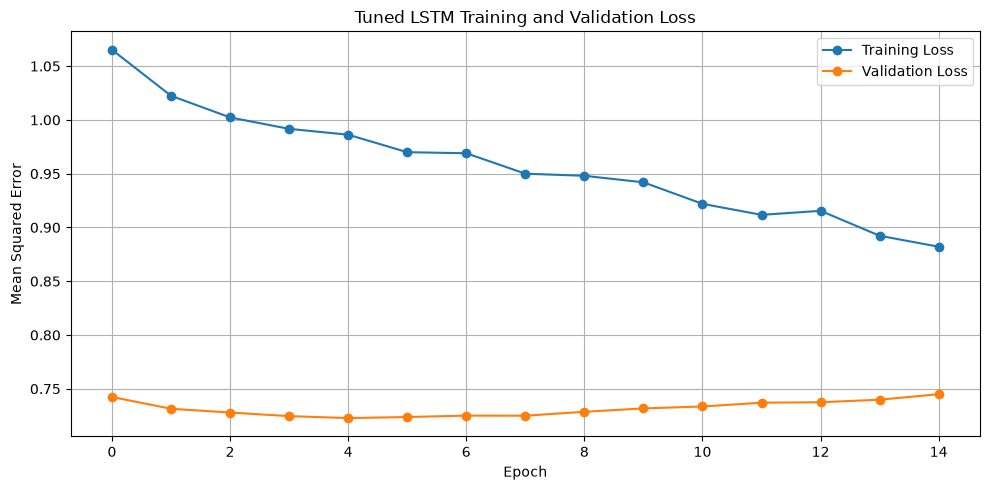

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    tuned_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    tuned_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Tuned LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 7.11 Tuned Model Actual Versus Predicted Returns

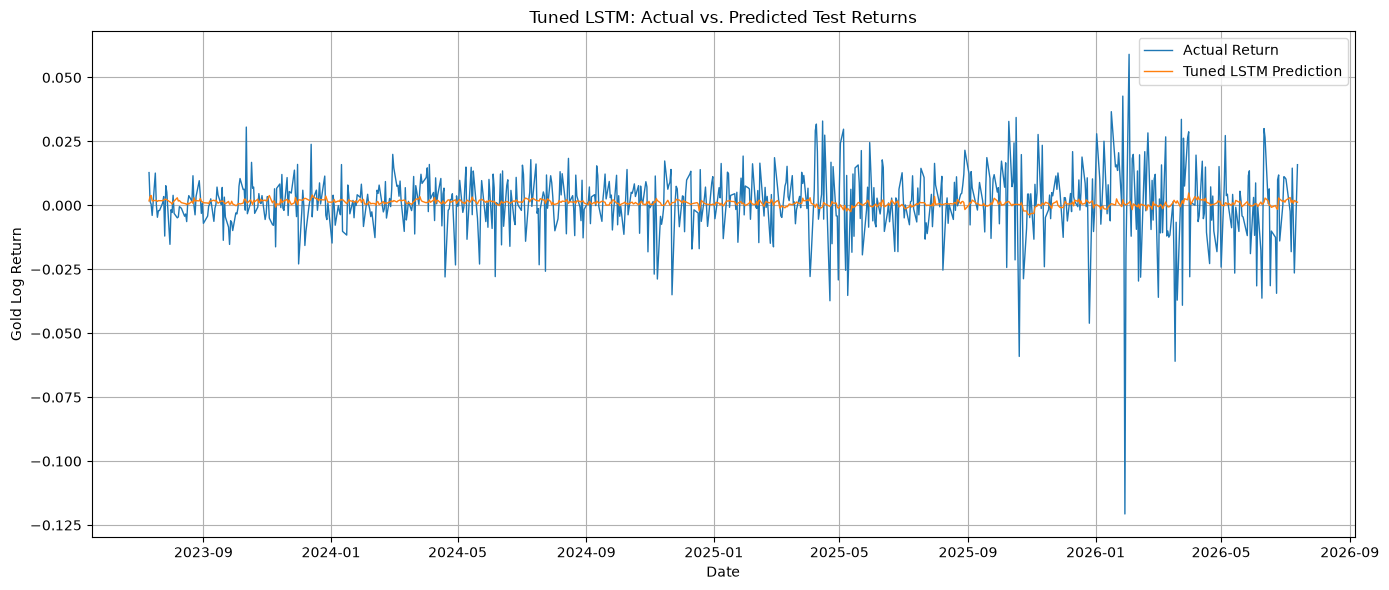

In [39]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test_actual,
    label="Actual Return",
    linewidth=1
)

plt.plot(
    test_dates,
    y_test_tuned_pred,
    label="Tuned LSTM Prediction",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Gold Log Return")
plt.title("Tuned LSTM: Actual vs. Predicted Test Returns")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 7.12 Tuned Model Residual Analysis

In [40]:
tuned_predictions = pd.DataFrame({
    "Date": test_dates,
    "Actual_Return": y_test_actual,
    "Predicted_Return": y_test_tuned_pred
})

tuned_predictions["Residual"] = (
    tuned_predictions["Actual_Return"]
    - tuned_predictions["Predicted_Return"]
)

tuned_predictions.head()

,Date,Actual_Return,Predicted_Return,Residual
0,2023-07-11,0.012810,0.001750,0.011060
1,2023-07-12,0.001532,0.003431,-0.001899
2,2023-07-13,0.000459,0.003872,-0.003412
3,2023-07-14,-0.003936,0.001722,-0.005658
4,2023-07-17,0.012622,0.001954,0.010668


In [41]:
print(
    tuned_predictions[
        [
            "Actual_Return",
            "Predicted_Return",
            "Residual"
        ]
    ].describe()
)

       Actual_Return  Predicted_Return    Residual
count     753.000000        753.000000  753.000000
mean        0.000987          0.000977    0.000010
std         0.013208          0.001082    0.013192
min        -0.120657         -0.003715   -0.121065
25%        -0.004733          0.000384   -0.005665
50%         0.001489          0.001019    0.000332
75%         0.007958          0.001722    0.007451
max         0.059054          0.004834    0.057984


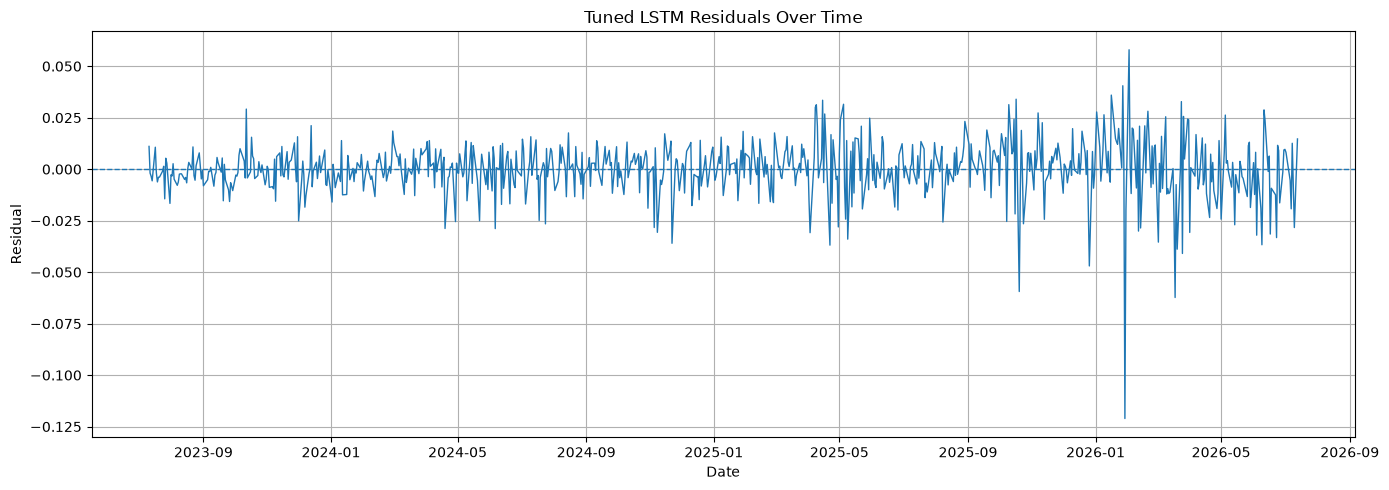

In [42]:
plt.figure(figsize=(14, 5))

plt.plot(
    tuned_predictions["Date"],
    tuned_predictions["Residual"],
    linewidth=1
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Tuned LSTM Residuals Over Time")
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Feature Importance (Permutation Importance)

### 8.1 Permutation Importance Strategy

LSTM does not expose coefficients or split-gain scores the way Lasso or XGBoost do, so feature importance is estimated using permutation importance. For each feature, its values are shuffled across all sequences in the validation set (keeping every other feature's values, and the temporal order within each sequence, intact), the tuned model re-predicts on the shuffled data, and the resulting increase in validation RMSE relative to the unperturbed model is recorded. A larger RMSE increase means the model relies more heavily on that feature. Each feature is shuffled 10 times with different random permutations, and the results are averaged to reduce noise from any single shuffle.

### 8.2 Unperturbed Validation RMSE

In [47]:
baseline_validation_pred_scaled = tuned_model.predict(
    X_validation_seq,
    verbose=0
)

baseline_validation_pred = target_scaler.inverse_transform(
    baseline_validation_pred_scaled
).ravel()

baseline_validation_actual = target_scaler.inverse_transform(
    y_validation_seq
).ravel()

baseline_validation_rmse = np.sqrt(
    mean_squared_error(
        baseline_validation_actual,
        baseline_validation_pred
    )
)

print("Unperturbed validation RMSE:", baseline_validation_rmse)

Unperturbed validation RMSE: 0.009908389204336608


### 8.3 Compute Permutation Importance

In [48]:
N_REPEATS = 10
permutation_rng = np.random.RandomState(SEED)

permutation_results = []

for feature_index, feature_name in enumerate(feature_columns):
    rmse_increases = []

    for repeat in range(N_REPEATS):
        X_validation_permuted = X_validation_seq.copy()

        # Shuffle this feature across samples, using the same
        # shuffled order at every timestep so each sample's
        # sequence stays internally consistent.
        shuffled_order = permutation_rng.permutation(
            X_validation_permuted.shape[0]
        )
        X_validation_permuted[:, :, feature_index] = (
            X_validation_permuted[shuffled_order, :, feature_index]
        )

        permuted_pred_scaled = tuned_model.predict(
            X_validation_permuted,
            verbose=0
        )
        permuted_pred = target_scaler.inverse_transform(
            permuted_pred_scaled
        ).ravel()

        permuted_rmse = np.sqrt(
            mean_squared_error(
                baseline_validation_actual,
                permuted_pred
            )
        )

        rmse_increases.append(permuted_rmse - baseline_validation_rmse)

    permutation_results.append({
        "Feature": feature_name,
        "Mean_RMSE_Increase": np.mean(rmse_increases),
        "Std_RMSE_Increase": np.std(rmse_increases),
    })

    print(
        f"{feature_name:<40} "
        f"mean RMSE increase = {np.mean(rmse_increases):.8f}"
    )

gold_return_1d                           mean RMSE increase = -0.00000910
gold_return_5d                           mean RMSE increase = -0.00000151
gold_return_20d                          mean RMSE increase = 0.00003500
gold_volatility_5d                       mean RMSE increase = 0.00001756
gold_volatility_20d                      mean RMSE increase = 0.00001476
gold_close_pos                           mean RMSE increase = 0.00000345
gold_volume_change                       mean RMSE increase = 0.00000532
gold_relative_volume                     mean RMSE increase = 0.00000925
crude_oil_return_1d                      mean RMSE increase = -0.00000370
silver_return_1d                         mean RMSE increase = 0.00003319
copper_return_1d                         mean RMSE increase = 0.00000144
platinum_return_1d                       mean RMSE increase = -0.00000200
us_dollar_index_return_1d                mean RMSE increase = 0.00002002
sp_500_return_1d                         mean R

### 8.4 Feature Importance Table

In [49]:
lstm_feature_importance = pd.DataFrame(
    permutation_results
).sort_values(
    by="Mean_RMSE_Increase",
    ascending=False
).reset_index(drop=True)

lstm_feature_importance["Rank"] = np.arange(
    1, len(lstm_feature_importance) + 1
)

lstm_feature_importance

,Feature,Mean_RMSE_Increase,Std_RMSE_Increase,Rank
0,breakeven_inflation_10y_diff_bps,4.553399e-05,0.000019,1
1,gold_return_20d,3.499574e-05,0.000014,2
2,silver_return_1d,3.319133e-05,0.000014,3
3,two_ten_slope,2.902615e-05,0.000028,4
4,us_dollar_index_return_1d,2.002451e-05,0.000019,5
5,gold_volatility_5d,1.755529e-05,0.000009,6
6,gold_volatility_20d,1.476397e-05,0.000009,7
7,gold_relative_volume,9.247728e-06,0.000006,8
8,vix_change_1d,8.669439e-06,0.000007,9
9,gold_volume_change,5.324768e-06,0.000012,10


### 8.5 Feature Importance Plot

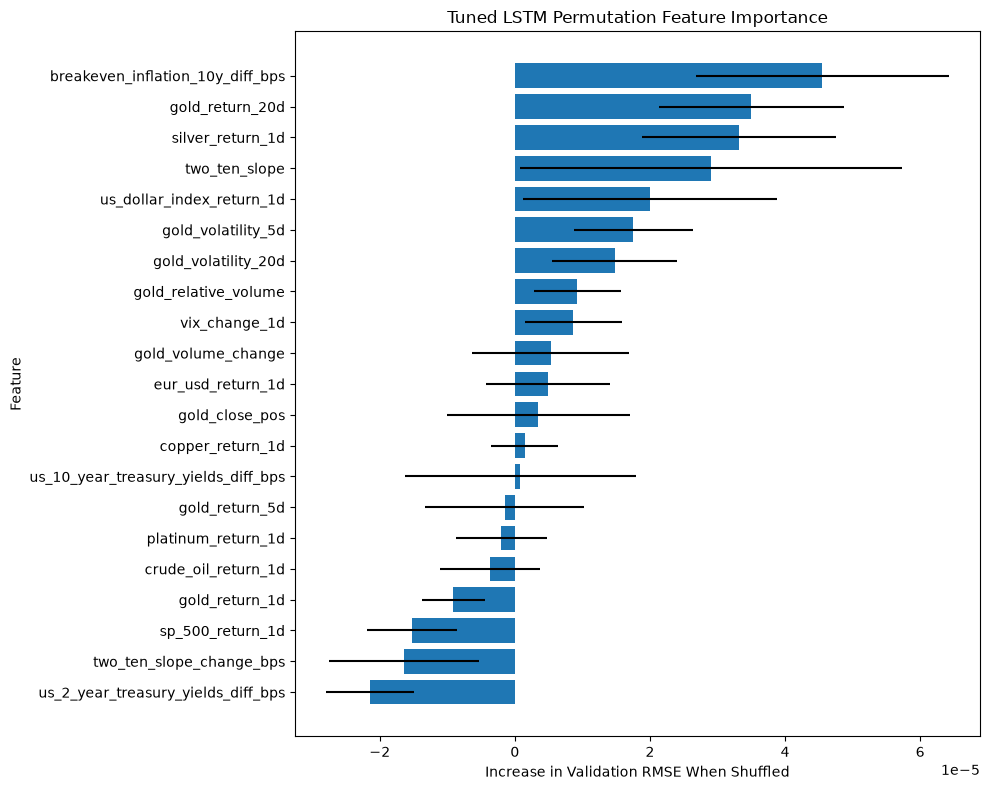

In [50]:
plot_data = lstm_feature_importance.sort_values(
    by="Mean_RMSE_Increase",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["Feature"],
    plot_data["Mean_RMSE_Increase"],
    xerr=plot_data["Std_RMSE_Increase"]
)

plt.xlabel("Increase in Validation RMSE When Shuffled")
plt.ylabel("Feature")
plt.title("Tuned LSTM Permutation Feature Importance")
plt.tight_layout()
plt.show()

Features with a larger increase in validation RMSE when shuffled are more important to the tuned LSTM's predictions. The top-ranked feature, breakeven_inflation_10y_diff_bps, increased validation RMSE by only about 4.55e-05 against an unperturbed baseline RMSE of 0.00991 — a relative increase of well under 1%. Several features near the bottom of the ranking show a small negative RMSE increase, which is sampling noise from averaging only 10 shuffles rather than a genuine improvement from removing that feature.

Given how small every RMSE increase is relative to the baseline, the honest interpretation is that the tuned LSTM does not depend heavily on any single feature; no predictor carries a strong, individually decisive signal. This is consistent with the model's near-zero R² on the test set and reinforces that the limiting factor is the weak information content of the feature set overall, rather than any one feature being uniquely important or unimportant.

## 9. Export LSTM Results

### 9.1 Export Model Metrics

In [43]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

lstm_metrics = pd.DataFrame({
    "Model": [
        "Zero-Return Baseline",
        "Baseline LSTM",
        "Tuned LSTM"
    ],
    "MAE": [
        zero_mae,
        baseline_mae,
        tuned_mae
    ],
    "MSE": [
        zero_mse,
        baseline_mse,
        tuned_mse
    ],
    "RMSE": [
        zero_rmse,
        baseline_rmse,
        tuned_rmse
    ],
    "R2": [
        zero_r2,
        baseline_r2,
        tuned_r2
    ],
    "Directional_Accuracy": [
        np.nan,
        baseline_directional_accuracy,
        tuned_directional_accuracy
    ]
})

lstm_metrics_path = RESULTS_DIR / "lstm_metrics.csv"
lstm_metrics.to_csv(lstm_metrics_path, index=False)

print(f"Saved metrics to: {lstm_metrics_path}")
lstm_metrics

Saved metrics to: results\lstm_metrics.csv


,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN
1,Baseline LSTM,0.009158,0.000174,0.013195,0.000614,0.557769
2,Tuned LSTM,0.009123,0.000174,0.013183,0.002461,0.564409


### 9.2 Export Test Predictions

In [44]:
lstm_predictions_export = pd.DataFrame({
    "Date": test_dates,
    "Actual_Return": y_test_actual,
    "Baseline_LSTM_Prediction": y_test_pred,
    "Tuned_LSTM_Prediction": y_test_tuned_pred
})

lstm_predictions_path = RESULTS_DIR / "lstm_predictions.csv"
lstm_predictions_export.to_csv(
    lstm_predictions_path,
    index=False
)

print(f"Saved predictions to: {lstm_predictions_path}")
lstm_predictions_export.head()

Saved predictions to: results\lstm_predictions.csv


,Date,Actual_Return,Baseline_LSTM_Prediction,Tuned_LSTM_Prediction
0,2023-07-11,0.012810,0.001436,0.001750
1,2023-07-12,0.001532,0.003837,0.003431
2,2023-07-13,0.000459,0.004483,0.003872
3,2023-07-14,-0.003936,0.002120,0.001722
4,2023-07-17,0.012622,0.001734,0.001954


### 9.3 Export Hyperparameter Tuning Results

In [45]:
tuning_results_path = RESULTS_DIR / "lstm_tuning_results.csv"

tuning_results_df.to_csv(
    tuning_results_path,
    index=False
)

print(f"Saved tuning results to: {tuning_results_path}")
tuning_results_df

Saved tuning results to: results\lstm_tuning_results.csv


,config_id,lstm_units,dropout_rate,learning_rate,batch_size,epochs_trained,best_epoch,best_validation_loss
0,5,64,0.3,0.0005,64,15,5,0.722769
1,4,32,0.4,0.0005,32,12,2,0.723751
2,3,32,0.3,0.0010,32,12,2,0.725200
3,2,32,0.2,0.0010,32,12,2,0.726241
4,1,16,0.2,0.0010,32,19,9,0.735474


### 9.4 Export Feature Importance

In [51]:
lstm_feature_importance_path = (
    RESULTS_DIR / "lstm_feature_importance.csv"
)

lstm_feature_importance.to_csv(
    lstm_feature_importance_path,
    index=False
)

print(
    "Saved feature importance to:",
    lstm_feature_importance_path
)

lstm_feature_importance.head()

Saved feature importance to: results\lstm_feature_importance.csv


,Feature,Mean_RMSE_Increase,Std_RMSE_Increase,Rank
0,breakeven_inflation_10y_diff_bps,0.000046,0.000019,1
1,gold_return_20d,0.000035,0.000014,2
2,silver_return_1d,0.000033,0.000014,3
3,two_ten_slope,0.000029,0.000028,4
4,us_dollar_index_return_1d,0.000020,0.000019,5


## 10. Conclusion

The LSTM models were trained to predict the next trading day's gold log return using 30-day sequences of 21 commodity, financial-market, and macroeconomic features.

The baseline LSTM slightly outperformed the zero-return benchmark. After hyperparameter tuning, the final LSTM achieved the best overall results:

- MAE: 0.00912251
- MSE: 0.00017380
- RMSE: 0.01318330
- R²: 0.0025
- Directional accuracy: 56.44%

Hyperparameter tuning produced small improvements over the baseline LSTM in every reported metric. The selected model used 64 LSTM units, a dropout rate of 0.3, a learning rate of 0.0005, and a batch size of 64.

Despite these improvements, the model explained very little of the variation in next-day gold returns. Its predictions remained concentrated near zero and did not capture large positive or negative market movements well. The residual plots also showed larger errors during periods of elevated volatility.

Overall, the LSTM demonstrated limited predictive value for return magnitude, although its directional accuracy was moderately above 50%. These results suggest that next-day gold returns are highly noisy and difficult to forecast using the current feature set and modeling approach

A permutation-based feature importance analysis (Section 8) found that no single feature carries a strong, individually decisive signal: even the top-ranked predictor (the change in 10-year breakeven inflation) increased validation RMSE by less than 1% when shuffled. This reinforces that the LSTM's limited predictive power stems from weak information content across the feature set as a whole, rather than from any one feature being disproportionately important.